# Соноправленность Т-теста и метода максимального правдоподобия
Т-тест и метод максимального правдоподобия (Likelihood) решают схожие задачи — оценку принадлежности исследуемых выборок одной популяции.

В данном исследовании будут проведены симуляции:
1. АА-тесты на базе одной генеральной совокупности;
2. АВ-тесты на базе двух разных генеральных совокупностей;

В каждой итерации симуляций будем рассчитывать выборочную статистику (среднее значение), проводить Т-тест и вычислять вероятность принадлежности группы А/В к популяции методом максимального правдоподобия.

По итогам симуляций проанализируем, как часто p-value Т-теста отклоняет нулевую гипотезу о равенстве средних и как это соотносится с результатами, полученными методом максимального правдоподобия.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt

## Functions

In [29]:
def get_populations(num_populations, params, size=1_000_000):
    """Возвращает популяцию с заданными параметрами.
    
    Args:
        num_populations: количество возвращаемых популяций;
        params: {mu_n: ..., sigma_n: ...}, где n – номер популяции
        size: размер популяции

    Returns: [numpy.ndarray]

    """

    rng = np.random.default_rng(seed=42)
    populations = []

    for i in range(1, num_populations + 1):
        mu = params.get(f'mu_{i}')
        sigma = params.get(f'sigma_{i}')

        if mu is None or sigma is None:
            raise ValueError(f"Отсутствуют параметры для популяции {i}: 'mu_{i}' и 'sigma_{i}'")

        population = rng.normal(size=size, loc=mu, scale=sigma)
        populations.append(population)

    return populations

In [33]:
def show_likelihood(value, data1, data2, mu_1, sigma_1, mu_2, sigma_2):
    """Возвращает вероятность "значения из популяции (или популяции по значению)" и визуализирует распределения
    
    Args:
        value:
        data1: 
        data2: 
        mu_1: 
        sigma_1: 
        mu_2: 
        sigma_2: 

    Returns:

    """

    # Посчитаем вероятность получить значение из популяции
    probability_1 = stats.norm.pdf(value, loc=mu_1, scale=sigma_1)
    probability_2 = stats.norm.pdf(value, loc=mu_2, scale=sigma_2)

    print(
        f'Вероятность получить значение {value} из Популяции №1 : {probability_1:.2%}\n'
        f'Вероятность получить значение {value} из Популяции №2 : {probability_2:.2%}\n'
    )

    # Построение гистограмм для двух выборок на одном графике
    plt.figure(figsize=(12, 5))
    sns.histplot(data1, kde=True, stat="probability", color='orange', label='population_1', alpha=0.9)
    sns.histplot(data2, kde=True, stat="probability", color='blue', label='population_2', alpha=0.3)

    # Добавляем вертикальную линию для выбранного значения
    plt.axvline(x=value, color='red', linestyle='--', label=f'Значение {value}')

    # Настроим подписи и легенду
    plt.xlabel('Значение')
    plt.ylabel('Вероятность')
    plt.legend()
    plt.title(f'Распределение вероятностей получить значение {value} из разных популяций')

    plt.show()

In [ ]:
def run_simulation(population, mu_1, sigma_1, sample_size=10_000):
    """Возвращает итоги одной симуляции
    
    Args:
        population: 
        mu_1: 
        sigma_1: 
        sample_size: 

    Returns: (sample_a_avg, sample_b_avg, t_stat, p_value, prob_a_true)

    """
    
    choice = lambda x: np.random.choice(x, size=sample_size, replace=True)
    sample_a, sample_b = choice(population), choice(population)
    sample_a_avg, sample_b_avg = np.mean(sample_a), np.mean(sample_b)
    t_stat, p_value = stats.ttest_ind(sample_a, sample_b)
    prob_a_true = stats.norm.pdf(sample_a_avg, loc=mu_1, scale=sigma_1)
    
    return sample_a_avg, sample_b_avg, t_stat, p_value, prob_a_true

## Likelihood (Правдоподобие).
Прежде чем переходить к симуляциям и тестам чуть-чуть пощупаем Likelihood. Попробуем его на двух популяциях очень близких друг к другу. И на двух популяциях отдаленных друг от друга.

Вероятность получить значение 20 из Популяции №1 : 4.57%
Вероятность получить значение 20 из Популяции №2 : 3.24%



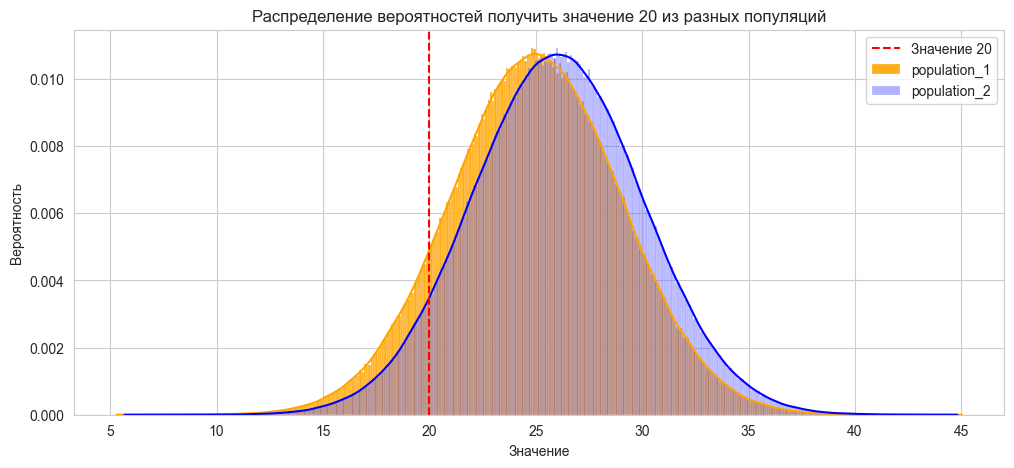

In [78]:
# Близкие популяции
params = {'mu_1': 25, 'sigma_1': 4, 'mu_2': 26, 'sigma_2': 4}
populations = get_populations(num_populations=2, params=params)

show_likelihood(value=20, data1=populations[0], data2=populations[1], **params)

Вероятность получить значение 20 из Популяции №1 : 4.57%
Вероятность получить значение 20 из Популяции №2 : 0.44%



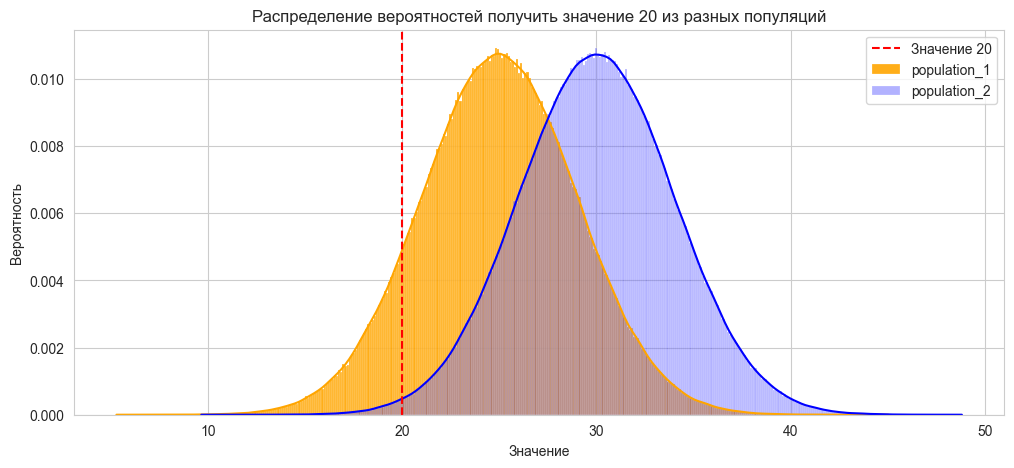

In [48]:
# Отдаленные популяции
params = {'mu_1': 25, 'sigma_1': 4, 'mu_2': 30, 'sigma_2': 4}
populations = get_populations(num_populations=2, params=params)

show_likelihood(value=20, data1=populations[0], data2=populations[1], **params)

## Симуляция АА-тестов
Вводные:
1. $H_{0}: A_{avg} = B_{avg}$;
2. $\alpha=0.05,\; \beta=0.2$;

In [145]:
# Генерируем одну большую популяцию
params = {'mu_1': 25, 'sigma_1': 4}
population = get_populations(num_populations=1, params=params)[0]

In [146]:
# Запускаем симуляции
results = [
    run_simulation(population=population, **params)
    for _ in tqdm(range(10_000), desc="Симуляции", unit="sim")
]

Симуляции: 100%|██████████| 10000/10000 [00:14<00:00, 670.04sim/s]


In [147]:
df = pd.DataFrame(
    results,
    columns=['sample_a_avg', 'sample_b_avg', 't_stat', 'p_value', 'prob_a_true']
)

In [148]:
df

,sample_a_avg,sample_b_avg,t_stat,p_value,prob_a_true
0,25.033888,25.042583,-0.154125,0.877513,0.099732
1,24.960568,25.073812,-1.983502,0.047325,0.099731
2,24.969769,24.907399,1.106705,0.268435,0.099733
3,24.993493,25.025979,-0.573902,0.566040,0.099735
4,25.012429,24.940235,1.268428,0.204660,0.099735
...,...,...,...,...,...
9995,25.020115,25.056715,-0.645810,0.518410,0.099734
9996,24.999387,25.024315,-0.441932,0.658543,0.099736
9997,25.049129,24.990608,1.036869,0.299809,0.099728
9998,25.014659,25.022455,-0.137353,0.890753,0.099735


### Оценка симуляции АА-тестов

In [149]:
# Доля Error I type для Т-теста
fp = df.query('p_value < 0.05').shape[0]
fpr = fp / df.shape[0]
print(f'Error I type: {fp} ({fpr:.2%})')

Error I type: 543 (5.43%)


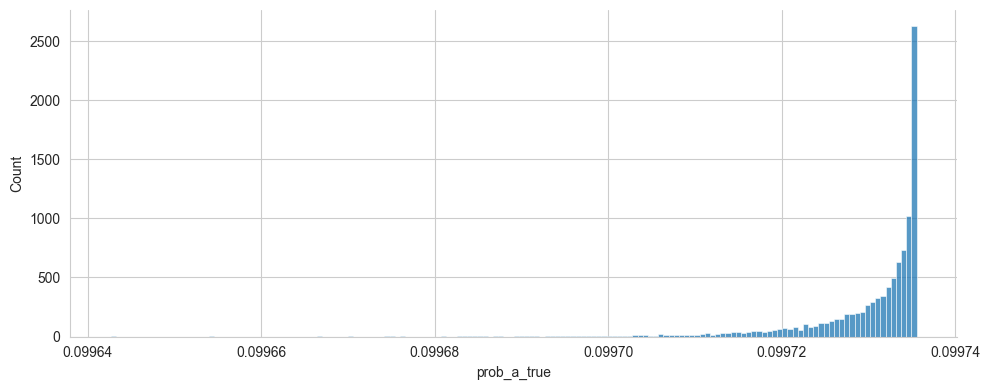

In [150]:
# Доля Error I type для likelihood
sns.displot(df['prob_a_true'], aspect=2.5, height=4);